# 재무지표 기반 투자 전략 백테스팅 예제

이 노트북의 목표는 **재무제표와 재무비율을 투자 전략으로 연결하고, 과거 데이터로 검증하는 흐름**을 보여주는 것입니다.

다루는 전략:

1. 저PER 전략
2. 저PBR 전략
3. 고배당 전략
4. 저PER + 저PBR 결합 전략
5. 시가총액 상위 종목 필터를 적용한 저PER 전략

> 수업용 핵심 메시지:  
> 재무비율은 단순히 외우는 숫자가 아니라, 투자 규칙으로 바꾸어 검증할 수 있는 데이터입니다.


## 0. 사전 준비

한국 주식 데이터는 `pykrx`를 사용합니다.

- 가격 데이터
- 시가총액
- PER, PBR, EPS, BPS, 배당수익률 등 기본 재무지표

수업 중 네트워크/API 문제가 생길 수 있으므로, 이 노트북은 두 가지 흐름을 모두 지원합니다.

1. `pykrx`로 데이터를 새로 가져오기
2. 이미 저장된 CSV 파일을 불러오기
3. 둘 다 없으면 샘플 데이터를 만들어 예제만 실행하기


In [ ]:
# 처음 한 번만 실행하면 됩니다.
# !pip install pykrx pandas numpy matplotlib

In [16]:
from pathlib import Path
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

FUNDAMENTALS_PATH = DATA_DIR / "fundamentals_yearly.csv"
PRICES_PATH = DATA_DIR / "prices_monthly.csv"

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

## 1. 리밸런싱 날짜 설정

이 예제에서는 매년 5월 초에 포트폴리오를 다시 구성한다고 가정합니다.

왜 5월인가?

- 한국 기업의 전년도 사업보고서는 보통 3월 말까지 제출됩니다.
- 5월 초를 기준으로 잡으면 전년도 재무정보가 어느 정도 시장 데이터에 반영되었다고 단순 가정하기 쉽습니다.
- 물론 실제 백테스팅에서는 보고서 제출일 기준으로 look-ahead bias를 더 엄격하게 관리해야 합니다.


In [17]:
# 매년 5월 첫 거래일 근처를 단순 지정한 예시입니다.
# 실제 수업에서는 이 리스트를 고정해두면 재현성이 좋아집니다.

REBALANCE_DATES = [
    "20140502", "20150504", "20160502", "20170502",
    "20180502", "20190502", "20200504", "20210503",
    "20220502", "20230502", "20240502", "20250502"
]

START_DATE = "20140101"
END_DATE = "20260501"

MARKET = "KOSPI"  # "KOSPI", "KOSDAQ", "ALL" 중 선택 가능

## 2. pykrx로 데이터 가져오기

아래 셀은 시간이 걸릴 수 있습니다.  
이미 CSV 파일이 있으면 다시 실행할 필요가 없습니다.

수집하는 데이터:

- 연도별 리밸런싱 시점의 재무지표: PER, PBR, EPS, BPS, DIV, DPS
- 연도별 리밸런싱 시점의 시가총액
- 월별 종가 데이터


In [18]:
def fetch_fundamentals_from_pykrx(rebalance_dates, market="KOSPI", sleep_sec=1.0):
    """리밸런싱 날짜별 전체 종목 재무지표와 시가총액을 수집합니다."""
    from pykrx import stock

    all_rows = []

    for date in rebalance_dates:
        print(f"Fetching fundamentals: {date}")

        fundamental = stock.get_market_fundamental_by_ticker(date, market=market)
        ohlcv = stock.get_market_ohlcv_by_ticker(date, market=market)
        market_cap = stock.get_market_cap_by_ticker(date, market=market)

        df = fundamental.join(ohlcv, how="left").join(market_cap, how="left", rsuffix="_mcap")
        df["date"] = pd.to_datetime(date)
        df["ticker"] = df.index
        df["name"] = [stock.get_market_ticker_name(ticker) for ticker in df.index]

        all_rows.append(df.reset_index(drop=True))
        time.sleep(sleep_sec)

    result = pd.concat(all_rows, ignore_index=True)
    return result


def fetch_monthly_prices_from_pykrx(start_date, end_date, base_date, market="KOSPI", sleep_sec=0.2, limit_tickers=None):
    """종목별 월별 OHLCV 데이터를 수집합니다."""
    from pykrx import stock

    tickers = stock.get_market_ticker_list(base_date, market=market)

    if limit_tickers is not None:
        tickers = tickers[:limit_tickers]

    price_rows = []

    for i, ticker in enumerate(tickers, start=1):
        name = stock.get_market_ticker_name(ticker)
        print(f"[{i}/{len(tickers)}] Fetching monthly prices: {ticker} {name}")

        try:
            df = stock.get_market_ohlcv(start_date, end_date, ticker, freq="m")
            if len(df) == 0:
                continue

            df = df.reset_index()
            df["ticker"] = ticker
            df["name"] = name
            price_rows.append(df)
        except Exception as e:
            print(f"  - skipped {ticker}: {e}")

        time.sleep(sleep_sec)

    result = pd.concat(price_rows, ignore_index=True)
    return result

In [19]:
# 실제 데이터를 새로 가져오고 싶을 때만 RUN_FETCH = True로 바꾸세요.
# 전체 KOSPI 월별 가격 수집은 시간이 걸릴 수 있습니다.

RUN_FETCH = False

if RUN_FETCH:
    fundamentals_raw = fetch_fundamentals_from_pykrx(REBALANCE_DATES, market=MARKET)
    fundamentals_raw.to_csv(FUNDAMENTALS_PATH, index=False, encoding="utf-8-sig")

    prices_raw = fetch_monthly_prices_from_pykrx(
        START_DATE,
        END_DATE,
        base_date=REBALANCE_DATES[-1],
        market=MARKET
    )
    prices_raw.to_csv(PRICES_PATH, index=False, encoding="utf-8-sig")

    print("Saved:")
    print(FUNDAMENTALS_PATH)
    print(PRICES_PATH)

## 3. 저장된 데이터 불러오기

실제 세미나에서는 수업 전에 CSV 파일을 만들어두고, 이 부분부터 시작하는 것을 추천합니다.


In [20]:
def load_saved_data():
    fundamentals = pd.read_csv(FUNDAMENTALS_PATH)
    prices = pd.read_csv(PRICES_PATH)

    fundamentals["date"] = pd.to_datetime(fundamentals["date"])
    prices["날짜"] = pd.to_datetime(prices["날짜"])

    return fundamentals, prices


if FUNDAMENTALS_PATH.exists() and PRICES_PATH.exists():
    fundamentals, prices = load_saved_data()
    print("Loaded saved CSV files.")
else:
    fundamentals, prices = None, None
    print("CSV files not found. We will create sample data in the next section.")

CSV files not found. We will create sample data in the next section.


## 4. 샘플 데이터 생성

실제 데이터 파일이 없거나 인터넷 연결이 안 되는 환경에서도 수업 흐름을 보여줄 수 있도록 샘플 데이터를 만듭니다.

주의: 이 샘플 데이터는 실제 투자 성과를 의미하지 않습니다.  
노트북 구조와 백테스팅 로직을 설명하기 위한 더미 데이터입니다.


In [21]:
def create_sample_data(rebalance_dates, n_tickers=120, seed=42):
    rng = np.random.default_rng(seed)

    tickers = [f"{i:06d}" for i in range(1, n_tickers + 1)]
    names = [f"샘플기업{i}" for i in range(1, n_tickers + 1)]

    fundamental_rows = []
    price_rows = []

    monthly_dates = pd.date_range("2014-01-31", "2026-05-31", freq="M")

    # 종목별 기초 특성
    quality = rng.normal(0, 1, n_tickers)
    value = rng.normal(0, 1, n_tickers)
    size = rng.normal(0, 1, n_tickers)

    for idx, (ticker, name) in enumerate(zip(tickers, names)):
        base_price = rng.uniform(5_000, 120_000)
        monthly_returns = rng.normal(0.006 + 0.002 * quality[idx] + 0.001 * value[idx], 0.09, len(monthly_dates))
        close = base_price * np.cumprod(1 + monthly_returns)

        for date, price in zip(monthly_dates, close):
            price_rows.append({
                "날짜": date,
                "ticker": ticker,
                "name": name,
                "종가": max(price, 100),
                "거래량": int(rng.integers(10_000, 2_000_000))
            })

        for date_str in rebalance_dates:
            date = pd.to_datetime(date_str)
            # value가 높을수록 낮은 PER/PBR로 가정
            per = max(2, rng.normal(14 - 3 * value[idx], 5))
            pbr = max(0.2, rng.normal(1.2 - 0.25 * value[idx], 0.5))
            div = max(0, rng.normal(2.0 + 0.3 * value[idx], 1.2))
            eps = rng.normal(4000 + 500 * quality[idx], 2500)
            bps = abs(rng.normal(50000 + 5000 * quality[idx], 15000))
            mcap = abs(rng.normal(1_000_000_000_000 * np.exp(size[idx]), 300_000_000_000))

            # 일부 결측/비정상 값 삽입
            if rng.random() < 0.08:
                per = 0
            if rng.random() < 0.05:
                pbr = 0

            fundamental_rows.append({
                "date": date,
                "ticker": ticker,
                "name": name,
                "BPS": bps,
                "PER": per,
                "PBR": pbr,
                "EPS": eps,
                "DIV": div,
                "DPS": div * price / 100,
                "종가": price,
                "시가총액": mcap,
                "상장주식수": mcap / max(price, 100),
            })

    fundamentals_sample = pd.DataFrame(fundamental_rows)
    prices_sample = pd.DataFrame(price_rows)

    return fundamentals_sample, prices_sample


if fundamentals is None or prices is None:
    fundamentals, prices = create_sample_data(REBALANCE_DATES)
    print("Sample data created.")

display(fundamentals.head())
display(prices.head())

Sample data created.


,date,ticker,name,BPS,PER,PBR,EPS,DIV,DPS,종가,시가총액,상장주식수
0,2014-05-02,000001,샘플기업1,38961.634337,11.709827,1.813073,1210.821741,4.089707,798.273518,19519.090206,4.867216e+11,2.493567e+07
1,2015-05-04,000001,샘플기업1,45169.486302,18.315673,2.366524,949.685523,0.000000,0.000000,19519.090206,2.599105e+11,1.331571e+07
2,2016-05-02,000001,샘플기업1,42109.772352,8.195682,1.713580,7338.476582,0.999904,195.172181,19519.090206,2.251025e+11,1.153243e+07
3,2017-05-02,000001,샘플기업1,55052.727073,19.310989,0.613076,1566.588411,2.338592,456.471898,19519.090206,1.103328e+10,5.652557e+05
4,2018-05-02,000001,샘플기업1,73291.268134,0.000000,1.812784,2617.416536,1.982924,387.048759,19519.090206,2.838913e+11,1.454429e+07


,날짜,ticker,name,종가,거래량
0,2014-01-31,000001,샘플기업1,24052.466472,296675
1,2014-02-28,000001,샘플기업1,26351.163553,1413758
2,2014-03-31,000001,샘플기업1,23987.930315,1508623
3,2014-04-30,000001,샘플기업1,23852.041663,781804
4,2014-05-31,000001,샘플기업1,27165.494207,1852042


## 5. 데이터 정리

백테스팅에서 특히 조심할 점:

- PER이 0이거나 음수인 기업은 제외
- PBR이 0이거나 음수인 기업은 제외
- 시가총액이 너무 작은 기업은 유동성 문제가 있을 수 있으므로 제외 가능
- 상장폐지 종목을 빼면 생존편향이 생길 수 있음
- 재무지표가 실제로 언제 투자자에게 공개되었는지 확인하지 않으면 look-ahead bias가 생길 수 있음


In [23]:
def clean_fundamentals(df):
    result = df.copy()

    # 컬럼명 통일
    result = result.rename(columns={
        "시가총액": "market_cap",
        "종가": "close"
    })

    result["date"] = pd.to_datetime(result["date"])
    result["ticker"] = result["ticker"].astype(str).str.zfill(6)

    for col in ["PER", "PBR", "EPS", "BPS", "DIV", "market_cap", "close"]:
        if col in result.columns:
            result[col] = pd.to_numeric(result[col], errors="coerce")

    # 분석에 필요한 핵심 값이 없는 행 제거
    result = result.dropna(subset=["date", "ticker", "PER", "PBR", "DIV", "market_cap"])

    return result


def clean_prices(df):
    result = df.copy()
    result["날짜"] = pd.to_datetime(result["날짜"])
    result["ticker"] = result["ticker"].astype(str).str.zfill(6)
    result["종가"] = pd.to_numeric(result["종가"], errors="coerce")
    result = result.dropna(subset=["날짜", "ticker", "종가"])
    return result


fundamentals_clean = clean_fundamentals(fundamentals)
prices_clean = clean_prices(prices)

display(fundamentals_clean.head())
display(prices_clean.head())

,date,ticker,name,BPS,PER,PBR,EPS,DIV,DPS,close,market_cap,상장주식수
0,2014-05-02,000001,샘플기업1,38961.634337,11.709827,1.813073,1210.821741,4.089707,798.273518,19519.090206,4.867216e+11,2.493567e+07
1,2015-05-04,000001,샘플기업1,45169.486302,18.315673,2.366524,949.685523,0.000000,0.000000,19519.090206,2.599105e+11,1.331571e+07
2,2016-05-02,000001,샘플기업1,42109.772352,8.195682,1.713580,7338.476582,0.999904,195.172181,19519.090206,2.251025e+11,1.153243e+07
3,2017-05-02,000001,샘플기업1,55052.727073,19.310989,0.613076,1566.588411,2.338592,456.471898,19519.090206,1.103328e+10,5.652557e+05
4,2018-05-02,000001,샘플기업1,73291.268134,0.000000,1.812784,2617.416536,1.982924,387.048759,19519.090206,2.838913e+11,1.454429e+07


,날짜,ticker,name,종가,거래량
0,2014-01-31,000001,샘플기업1,24052.466472,296675
1,2014-02-28,000001,샘플기업1,26351.163553,1413758
2,2014-03-31,000001,샘플기업1,23987.930315,1508623
3,2014-04-30,000001,샘플기업1,23852.041663,781804
4,2014-05-31,000001,샘플기업1,27165.494207,1852042


## 6. 다음 리밸런싱 시점까지의 수익률 계산

매년 5월에 종목을 고르고, 다음 해 5월까지 보유한다고 가정합니다.

수익률 계산 방식:

\[
수익률 = \frac{다음\ 리밸런싱\ 시점의\ 가격}{현재\ 리밸런싱\ 시점의\ 가격} - 1
\]

단순화를 위해 배당은 제외합니다.  
실제 백테스팅에서는 배당 포함 총수익률을 쓰는 것이 더 좋습니다.


In [24]:
def get_nearest_monthly_price(prices_df, ticker, target_date):
    """target_date 이후 가장 가까운 월별 가격을 찾습니다."""
    sub = prices_df[(prices_df["ticker"] == ticker) & (prices_df["날짜"] >= target_date)].sort_values("날짜")
    if len(sub) == 0:
        return np.nan
    return sub.iloc[0]["종가"]


def add_forward_returns(fundamentals_df, prices_df, rebalance_dates):
    result_rows = []
    date_list = [pd.to_datetime(d) for d in rebalance_dates]

    for current_date, next_date in zip(date_list[:-1], date_list[1:]):
        universe = fundamentals_df[fundamentals_df["date"] == current_date].copy()

        if len(universe) == 0:
            continue

        current_prices = []
        next_prices = []

        for ticker in universe["ticker"]:
            current_price = get_nearest_monthly_price(prices_df, ticker, current_date)
            next_price = get_nearest_monthly_price(prices_df, ticker, next_date)
            current_prices.append(current_price)
            next_prices.append(next_price)

        universe["current_price"] = current_prices
        universe["next_price"] = next_prices
        universe["next_date"] = next_date
        universe["next_return"] = universe["next_price"] / universe["current_price"] - 1

        result_rows.append(universe)

    result = pd.concat(result_rows, ignore_index=True)
    result = result.dropna(subset=["next_return"])
    return result


backtest_data = add_forward_returns(fundamentals_clean, prices_clean, REBALANCE_DATES)

display(backtest_data.head())
print(backtest_data.shape)

,date,ticker,name,BPS,PER,PBR,EPS,DIV,DPS,close,market_cap,상장주식수,current_price,next_price,next_date,next_return
0,2014-05-02,000001,샘플기업1,38961.634337,11.709827,1.813073,1210.821741,4.089707,798.273518,19519.090206,4.867216e+11,2.493567e+07,27165.494207,36441.212119,2015-05-04,0.341452
1,2014-05-02,000002,샘플기업2,25644.832794,21.403554,0.844077,2916.429324,4.526140,2482.968387,54858.402875,9.310197e+11,1.697132e+07,112128.219189,75008.471270,2015-05-04,-0.331047
2,2014-05-02,000003,샘플기업3,62145.361538,8.835525,1.406976,2933.607367,2.940456,4883.334330,166074.043858,3.422925e+11,2.061083e+06,52344.240208,45260.374761,2015-05-04,-0.135332
3,2014-05-02,000004,샘플기업4,62970.699512,16.741689,0.741874,2462.182128,0.270871,347.624182,128335.912016,3.492586e+11,2.721441e+06,22529.563132,25884.489015,2015-05-04,0.148912
4,2014-05-02,000005,샘플기업5,43778.372116,12.280830,0.886706,2097.536982,3.064762,443.709566,14477.781619,8.670114e+12,5.988565e+08,69353.831634,57153.270986,2015-05-04,-0.175918


(1320, 16)


## 7. 투자 전략 정의

이 예제에서는 동일가중 포트폴리오를 사용합니다.

즉, 선택된 종목을 모두 같은 비중으로 산다고 가정합니다.

전략:

1. 시장 전체: 모든 종목 동일가중
2. 저PER: PER이 낮은 상위 20%
3. 저PBR: PBR이 낮은 상위 20%
4. 고배당: 배당수익률이 높은 상위 20%
5. 저PER + 저PBR: PER 하위 30% 안에서 PBR 하위 30%
6. 대형주 저PER: 시가총액 상위 200개 중 PER 하위 20%


In [25]:
def select_market(df):
    return df.copy()


def select_low_per(df, quantile=0.2):
    valid = df[df["PER"] > 0].copy()
    cutoff = valid["PER"].quantile(quantile)
    return valid[valid["PER"] <= cutoff]


def select_low_pbr(df, quantile=0.2):
    valid = df[df["PBR"] > 0].copy()
    cutoff = valid["PBR"].quantile(quantile)
    return valid[valid["PBR"] <= cutoff]


def select_high_dividend(df, quantile=0.8):
    valid = df[df["DIV"] > 0].copy()
    cutoff = valid["DIV"].quantile(quantile)
    return valid[valid["DIV"] >= cutoff]


def select_low_per_low_pbr(df, quantile=0.3):
    valid = df[(df["PER"] > 0) & (df["PBR"] > 0)].copy()
    per_cutoff = valid["PER"].quantile(quantile)
    pbr_cutoff = valid["PBR"].quantile(quantile)
    return valid[(valid["PER"] <= per_cutoff) & (valid["PBR"] <= pbr_cutoff)]


def select_large_cap_low_per(df, top_n=200, quantile=0.2):
    valid = df[(df["PER"] > 0) & (df["market_cap"] > 0)].copy()
    large = valid.sort_values("market_cap", ascending=False).head(top_n)
    cutoff = large["PER"].quantile(quantile)
    return large[large["PER"] <= cutoff]


STRATEGIES = {
    "Market Equal Weight": select_market,
    "Low PER": select_low_per,
    "Low PBR": select_low_pbr,
    "High Dividend": select_high_dividend,
    "Low PER + Low PBR": select_low_per_low_pbr,
    "Large-Cap Low PER": select_large_cap_low_per,
}

## 8. 백테스팅 실행

각 리밸런싱 날짜마다 전략별로 종목을 고른 뒤, 다음 리밸런싱 날짜까지의 평균 수익률을 계산합니다.


In [26]:
def run_backtest(data, strategies):
    rows = []

    for date, group in data.groupby("date"):
        for strategy_name, selector in strategies.items():
            selected = selector(group)

            if len(selected) == 0:
                portfolio_return = np.nan
            else:
                portfolio_return = selected["next_return"].mean()

            rows.append({
                "date": date,
                "strategy": strategy_name,
                "n_stocks": len(selected),
                "return": portfolio_return,
                "avg_PER": selected["PER"].replace(0, np.nan).mean() if len(selected) else np.nan,
                "avg_PBR": selected["PBR"].replace(0, np.nan).mean() if len(selected) else np.nan,
                "avg_DIV": selected["DIV"].replace(0, np.nan).mean() if len(selected) else np.nan,
            })

    result = pd.DataFrame(rows)
    result = result.sort_values(["strategy", "date"])
    result["cumulative_return"] = result.groupby("strategy")["return"].transform(lambda x: (1 + x.fillna(0)).cumprod() - 1)

    return result


backtest_result = run_backtest(backtest_data, STRATEGIES)

display(backtest_result.head(12))

,date,strategy,n_stocks,return,avg_PER,avg_PBR,avg_DIV,cumulative_return
3,2014-05-02,High Dividend,24,0.227057,13.033417,1.258635,3.788579,0.227057
9,2015-05-04,High Dividend,23,0.054261,13.278383,1.055781,3.582777,0.293639
15,2016-05-02,High Dividend,23,0.156932,12.709370,1.085589,3.784523,0.496652
21,2017-05-02,High Dividend,23,0.066436,13.159686,0.988160,3.800171,0.596084
27,2018-05-02,High Dividend,23,0.068203,12.995025,1.167681,3.747745,0.704942
33,2019-05-02,High Dividend,22,0.075009,14.171664,1.029894,3.750916,0.832828
39,2020-05-04,High Dividend,23,0.135057,12.905154,1.309951,3.719828,1.080365
45,2021-05-03,High Dividend,23,0.161059,14.308644,1.017698,3.691646,1.415426
51,2022-05-02,High Dividend,24,0.114723,12.897368,1.014782,3.746248,1.692532
57,2023-05-02,High Dividend,24,0.088691,11.805302,1.112268,3.785049,1.931336


## 9. 성과 요약

확인할 지표:

- 연평균 수익률
- 누적 수익률
- 변동성
- 최대낙폭
- 승률
- 평균 편입 종목 수


In [27]:
def max_drawdown(returns):
    wealth = (1 + returns.fillna(0)).cumprod()
    peak = wealth.cummax()
    drawdown = wealth / peak - 1
    return drawdown.min()


def summarize_performance(result):
    rows = []

    for strategy, group in result.groupby("strategy"):
        returns = group["return"].dropna()
        if len(returns) == 0:
            continue

        total_return = (1 + returns).prod() - 1
        annual_return = (1 + total_return) ** (1 / len(returns)) - 1
        volatility = returns.std()
        mdd = max_drawdown(returns)
        win_rate = (returns > 0).mean()
        avg_n_stocks = group["n_stocks"].mean()

        rows.append({
            "strategy": strategy,
            "periods": len(returns),
            "annual_return": annual_return,
            "total_return": total_return,
            "volatility": volatility,
            "max_drawdown": mdd,
            "win_rate": win_rate,
            "avg_n_stocks": avg_n_stocks,
        })

    summary = pd.DataFrame(rows)
    summary = summary.sort_values("annual_return", ascending=False)
    return summary


summary = summarize_performance(backtest_result)

summary_display = summary.copy()

for col in ["annual_return", "total_return", "volatility", "max_drawdown", "win_rate"]:
    if col in summary_display.columns:
        summary_display[col] = summary_display[col].map(lambda x: f"{x:.2%}")

display(summary_display)

,strategy,periods,annual_return,total_return,volatility,max_drawdown,win_rate,avg_n_stocks
4,Low PER + Low PBR,11,10.22%,191.66%,9.82%,-2.14%,81.82%,13.818182
0,High Dividend,11,10.18%,190.43%,6.43%,-0.92%,90.91%,23.181818
2,Low PBR,11,9.91%,182.83%,6.65%,-1.63%,81.82%,23.000000
1,Large-Cap Low PER,11,9.19%,162.92%,9.99%,-5.11%,72.73%,22.363636
3,Low PER,11,9.19%,162.92%,9.99%,-5.11%,72.73%,22.363636
5,Market Equal Weight,11,9.05%,159.31%,3.64%,0.00%,100.00%,120.000000


## 10. 누적수익률 시각화

전략별 누적수익률을 비교합니다.


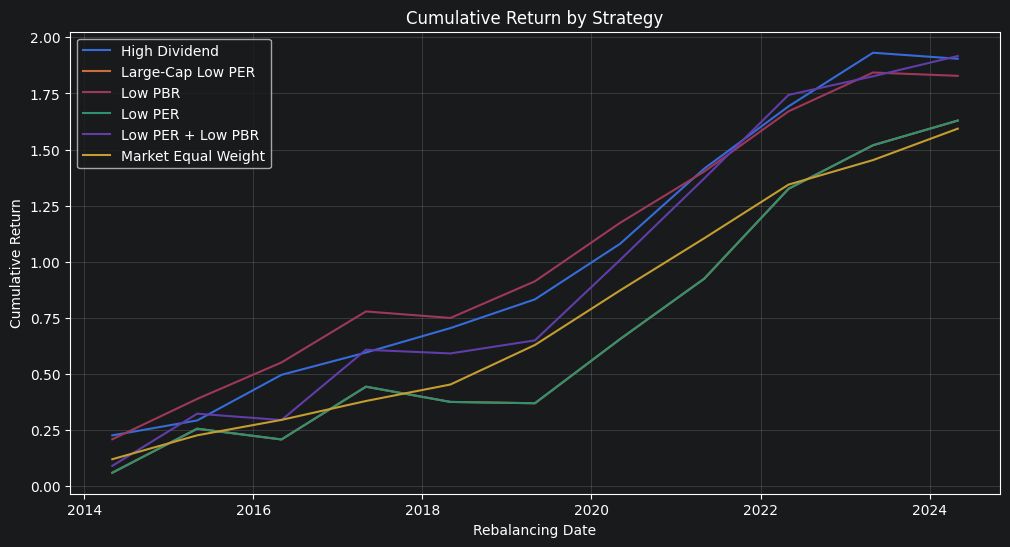

In [28]:
plt.figure(figsize=(12, 6))

for strategy, group in backtest_result.groupby("strategy"):
    group = group.sort_values("date")
    plt.plot(group["date"], group["cumulative_return"], label=strategy)

plt.title("Cumulative Return by Strategy")
plt.xlabel("Rebalancing Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 11. 연도별 수익률 비교

각 전략이 매년 항상 좋은 것은 아닙니다.  
백테스팅에서 중요한 것은 단순히 최종 수익률만 보는 것이 아니라, **어떤 시기에 강하고 약했는지**를 함께 보는 것입니다.


strategy,High Dividend,Large-Cap Low PER,Low PBR,Low PER,Low PER + Low PBR,Market Equal Weight
date,,,,,,
2014-05-02,22.71%,6.07%,20.95%,6.07%,9.12%,12.09%
2015-05-04,5.43%,18.48%,14.89%,18.48%,21.31%,9.50%
2016-05-02,15.69%,-3.81%,11.68%,-3.81%,-2.14%,5.59%
2017-05-02,6.64%,19.45%,14.64%,19.45%,24.15%,6.49%
2018-05-02,6.82%,-4.70%,-1.63%,-4.70%,-1.01%,5.32%
2019-05-02,7.50%,-0.43%,9.33%,-0.43%,3.65%,12.11%
2020-05-04,13.51%,20.85%,13.61%,20.85%,21.71%,14.91%
2021-05-03,16.11%,16.27%,10.52%,16.27%,18.09%,12.41%
2022-05-02,11.47%,20.79%,11.16%,20.79%,15.67%,11.34%


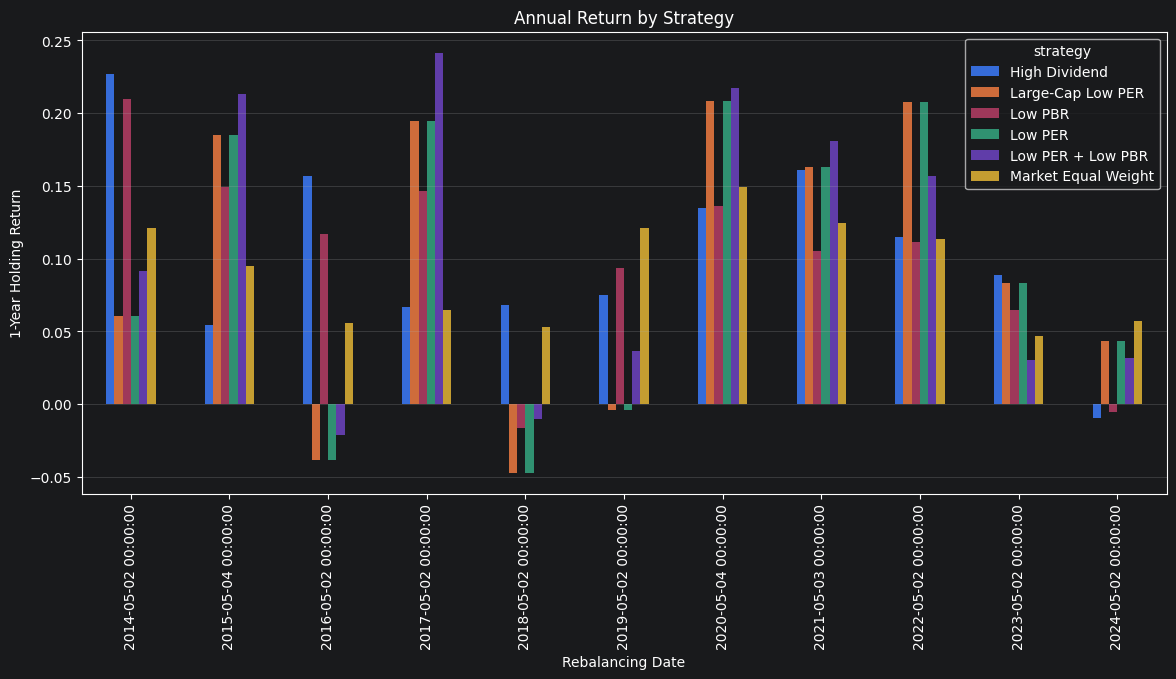

In [30]:
pivot_returns = backtest_result.pivot(
    index="date",
    columns="strategy",
    values="return"
)

# Display without using .style, so it does not require jinja2
pivot_returns_display = pivot_returns.copy()

for col in pivot_returns_display.columns:
    pivot_returns_display[col] = pivot_returns_display[col].map(
        lambda x: f"{x:.2%}" if pd.notna(x) else ""
    )

display(pivot_returns_display)

# Plot annual returns by strategy
pivot_returns.plot(kind="bar", figsize=(14, 6))

plt.title("Annual Return by Strategy")
plt.xlabel("Rebalancing Date")
plt.ylabel("1-Year Holding Return")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## 12. 특정 전략의 편입 종목 확인

백테스팅 결과만 보면 숫자놀음이 되기 쉽습니다.  
실제로 어떤 종목이 선택되었는지 확인해야 전략의 의미를 이해할 수 있습니다.


In [32]:
def show_selected_stocks(data, date, strategy_name, top_n=20):
    date = pd.to_datetime(date)

    group = data[data["date"] == date]

    if strategy_name not in STRATEGIES:
        raise ValueError(f"Unknown strategy: {strategy_name}")

    selected = STRATEGIES[strategy_name](group)

    cols = [
        "date",
        "ticker",
        "name",
        "PER",
        "PBR",
        "DIV",
        "market_cap",
        "next_return"
    ]

    selected = selected[cols].sort_values("next_return", ascending=False)

    return selected.head(top_n)


show_selected_stocks(
    backtest_data,
    "2024-05-02",
    "Low PER",
    top_n=20
)

,date,ticker,name,PER,PBR,DIV,market_cap,next_return
1217,2024-05-02,000018,샘플기업18,7.014260,2.016375,0.512348,7.951327e+11,0.574106
1273,2024-05-02,000074,샘플기업74,8.563670,1.173483,3.255721,1.615259e+12,0.539557
1280,2024-05-02,000081,샘플기업81,8.725414,0.000000,2.905703,2.290684e+12,0.355992
1251,2024-05-02,000052,샘플기업52,9.755915,0.567155,4.109245,1.301164e+12,0.293788
1281,2024-05-02,000082,샘플기업82,3.771890,0.431010,0.949367,8.155991e+11,0.291680
1269,2024-05-02,000070,샘플기업70,9.771567,0.534264,2.325409,5.685704e+12,0.228348
1235,2024-05-02,000036,샘플기업36,9.937143,0.762686,2.782822,1.471884e+12,0.168303
1204,2024-05-02,000005,샘플기업5,2.480385,0.615142,1.159610,8.425457e+12,0.135634
1212,2024-05-02,000013,샘플기업13,8.889468,1.888095,0.930041,6.161177e+12,0.127569
1216,2024-05-02,000017,샘플기업17,2.000000,2.327244,2.773745,1.440372e+12,0.123603


## 13. 수업에서 강조할 한계

이 예제는 교육용입니다. 실제 투자 전략 검증에는 더 많은 주의가 필요합니다.

대표적인 한계:

1. **생존편향**  
   현재 남아 있는 종목만 쓰면 과거에 상장폐지된 기업이 빠질 수 있습니다.

2. **look-ahead bias**  
   특정 시점에 실제로 알 수 없었던 재무정보를 사용하면 결과가 과대평가됩니다.

3. **거래비용과 세금 미반영**  
   매매수수료, 세금, 슬리피지 등을 반영해야 실제 수익률에 가까워집니다.

4. **배당 미반영**  
   장기 백테스팅에서는 가격수익률보다 배당 포함 총수익률이 더 적절합니다.

5. **소형주 유동성 문제**  
   시가총액이 작은 종목은 실제로 원하는 가격에 매수·매도하기 어려울 수 있습니다.

6. **단일 지표의 위험**  
   PER, PBR 하나만으로 기업을 평가하면 회계 왜곡, 경기순환, 일회성 이익을 놓칠 수 있습니다.


## 14. 마무리 질문

수업 마지막에 다음 질문을 던지면 좋습니다.

- 저PER 전략이 항상 좋은가?
- 저PBR 기업은 정말 싼 기업인가, 아니면 문제가 있는 기업인가?
- 고배당 기업은 안정적인가, 아니면 성장 기회가 부족한 기업인가?
- 좋은 전략은 높은 수익률만으로 판단할 수 있는가?
- 재무제표 지식은 백테스팅 결과를 해석하는 데 왜 필요한가?

핵심 결론:

> 백테스팅은 정답을 알려주는 도구가 아니라, 투자 아이디어를 검증하고 질문을 더 정교하게 만드는 도구입니다.
